/var/folders/ml/rzck8tbd3wlfxlcx23nf59zm0000gn/T/ipykernel_93171/2930995188.py:44: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  precip_df_hourly = precip_df.set_index('time').resample('H')['rain_mm_min'].sum().reset_index()
/var/folders/ml/rzck8tbd3wlfxlcx23nf59zm0000gn/T/ipykernel_93171/2930995188.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


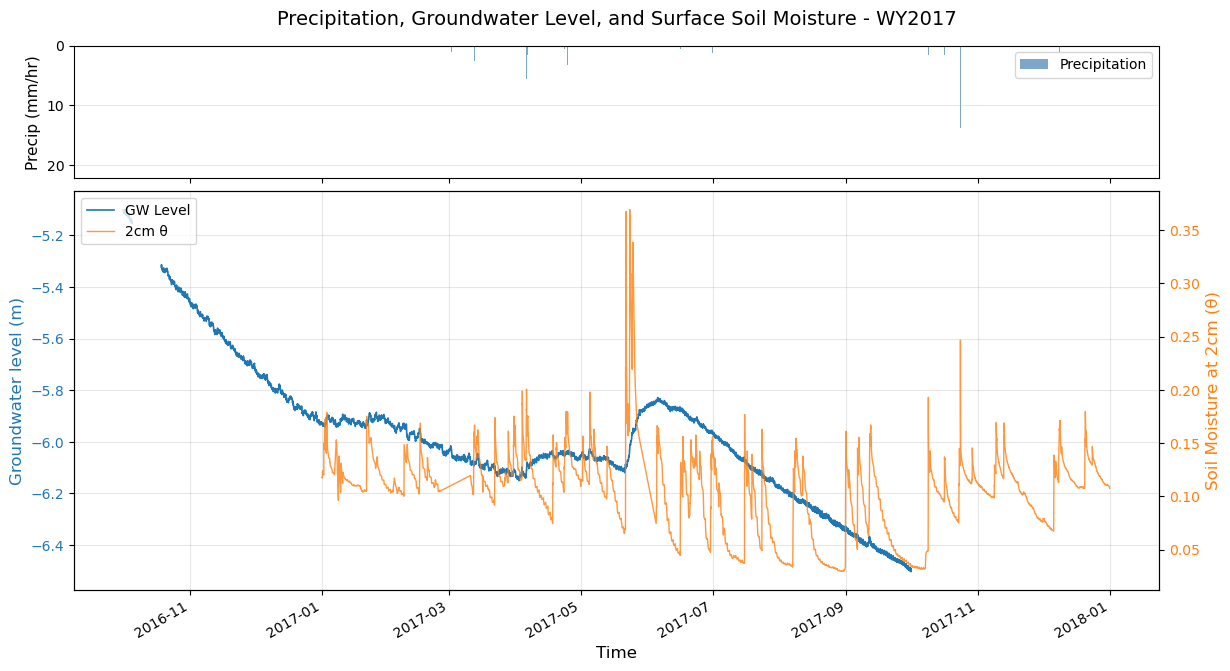


=== Precipitation Data Summary ===
Date range: 2017-02-17 22:30:00 to 2018-01-01 00:00:00
Total precipitation: 500.89 mm
Max hourly precip: 21.08 mm/hr

=== Groundwater Data Summary ===
                      time       level_m
count                26280  25312.000000
mean   2017-04-01 11:50:00     -5.980875
min    2016-10-01 00:00:00     -6.502219
25%    2016-12-31 05:55:00     -6.108535
50%    2017-04-01 11:50:00     -6.013107
75%    2017-07-01 17:45:00     -5.879243
max    2017-09-30 23:40:00     -5.100074
std                    NaN      0.257012

Date range: 2016-10-01 00:00:00 to 2017-09-30 23:40:00

=== Soil Moisture Data Summary ===
                                time     theta_2cm
count                          14970  14970.000000
mean   2017-07-21 22:02:19.238477056      0.102317
min              2017-01-01 00:30:00      0.029551
25%              2017-04-30 01:07:30      0.077634
50%              2017-07-25 04:15:00      0.109340
75%              2017-10-15 00:52:30      0.12

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ========== Load Groundwater Data ==========
csv_path = "/Users/jasonjing/Documents/smap/SMAP-Recharge-Flux/data/DeepWellWY2017.csv"

# Load CSV
gw_df = pd.read_csv(csv_path)
# Normalize/rename columns
gw_df.columns = [c.strip() for c in gw_df.columns]
gw_df = gw_df.rename(columns={"Time": "time", "level (mm)": "level_mm", "Level (mm)": "level_mm"})

# Parse datetime (format like '10/1/16 0:00')
gw_df["time"] = pd.to_datetime(gw_df["time"], format="%m/%d/%y %H:%M", errors="coerce")
gw_df = gw_df.dropna(subset=["time"]).sort_values("time").reset_index(drop=True)

# Convert to meters
gw_df["level_m"] = gw_df["level_mm"] / 1000.0

# ========== Load Soil Moisture and Precipitation Data ==========
sm_path = "/Users/jasonjing/Documents/smap/SMAP-Recharge-Flux/data/2017_HalfHourly_UTC_ForestSite1.xlsx"

# Load Excel with multi-level headers
sm_df_raw = pd.read_excel(sm_path, header=[0, 1])

# Extract time, 2cm theta, and precipitation with proper multi-index handling
time_col = ('Unnamed: 0_level_0', 'Date Time')
theta_col = ('CR1000_2589', '2cm theta')
rain_col = ('CR5000', 'Rain_mm_min')

# Create a new dataframe with flattened columns
sm_df = pd.DataFrame()
sm_df['time'] = pd.to_datetime(sm_df_raw[time_col], errors='coerce')
sm_df['theta_2cm'] = pd.to_numeric(sm_df_raw[theta_col], errors='coerce')
sm_df['rain_mm_min'] = pd.to_numeric(sm_df_raw[rain_col], errors='coerce')

# Filter out missing data indicators (negative values like -9999)
sm_df.loc[sm_df['theta_2cm'] < 0, 'theta_2cm'] = np.nan
sm_df.loc[sm_df['rain_mm_min'] < 0, 'rain_mm_min'] = np.nan

# For precipitation, aggregate to hourly
precip_df = sm_df[['time', 'rain_mm_min']].dropna().copy()
precip_df_hourly = precip_df.set_index('time').resample('H')['rain_mm_min'].sum().reset_index()
precip_df_hourly.columns = ['time', 'rain_mm']

# For theta, remove NaN values
sm_df = sm_df.dropna(subset=['time', 'theta_2cm']).sort_values('time').reset_index(drop=True)

# ========== Plot Comparison ==========
fig, (ax_precip, ax1) = plt.subplots(2, 1, figsize=(14, 8), 
                                      gridspec_kw={'height_ratios': [1, 3], 'hspace': 0.05},
                                      sharex=True)

# Plot precipitation on top subplot (inverted)
ax_precip.bar(precip_df_hourly['time'], precip_df_hourly['rain_mm'], 
              width=0.04, color='steelblue', alpha=0.7, label='Precipitation')
ax_precip.set_ylabel('Precip (mm/hr)', fontsize=11)
ax_precip.invert_yaxis()  # Invert so rain falls from top
ax_precip.legend(loc='upper right')
ax_precip.grid(True, alpha=0.3, axis='y')

# Plot groundwater level on left y-axis
color1 = 'tab:blue'
ax1.set_xlabel('Time', fontsize=12)
ax1.set_ylabel('Groundwater level (m)', color=color1, fontsize=12)
ax1.plot(gw_df['time'], gw_df['level_m'], color=color1, lw=1.2, label='GW Level')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Create second y-axis for soil moisture
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Soil Moisture at 2cm (θ)', color=color2, fontsize=12)
ax2.plot(sm_df['time'], sm_df['theta_2cm'], color=color2, lw=1.0, alpha=0.8, label='2cm θ')
ax2.tick_params(axis='y', labelcolor=color2)

# Title and formatting
ax_precip.set_title('Precipitation, Groundwater Level, and Surface Soil Moisture - WY2017', 
                    fontsize=14, pad=15)
fig.autofmt_xdate()

# Add legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

# Show summary statistics
print("\n=== Precipitation Data Summary ===")
print(f"Date range: {precip_df['time'].min()} to {precip_df['time'].max()}")
print(f"Total precipitation: {precip_df['rain_mm_min'].sum():.2f} mm")
print(f"Max hourly precip: {precip_df_hourly['rain_mm'].max():.2f} mm/hr")

print("\n=== Groundwater Data Summary ===")
print(gw_df[['time', 'level_m']].describe())
print(f"\nDate range: {gw_df['time'].min()} to {gw_df['time'].max()}")

print("\n=== Soil Moisture Data Summary ===")
print(sm_df[['time', 'theta_2cm']].describe())
print(f"\nDate range: {sm_df['time'].min()} to {sm_df['time'].max()}")

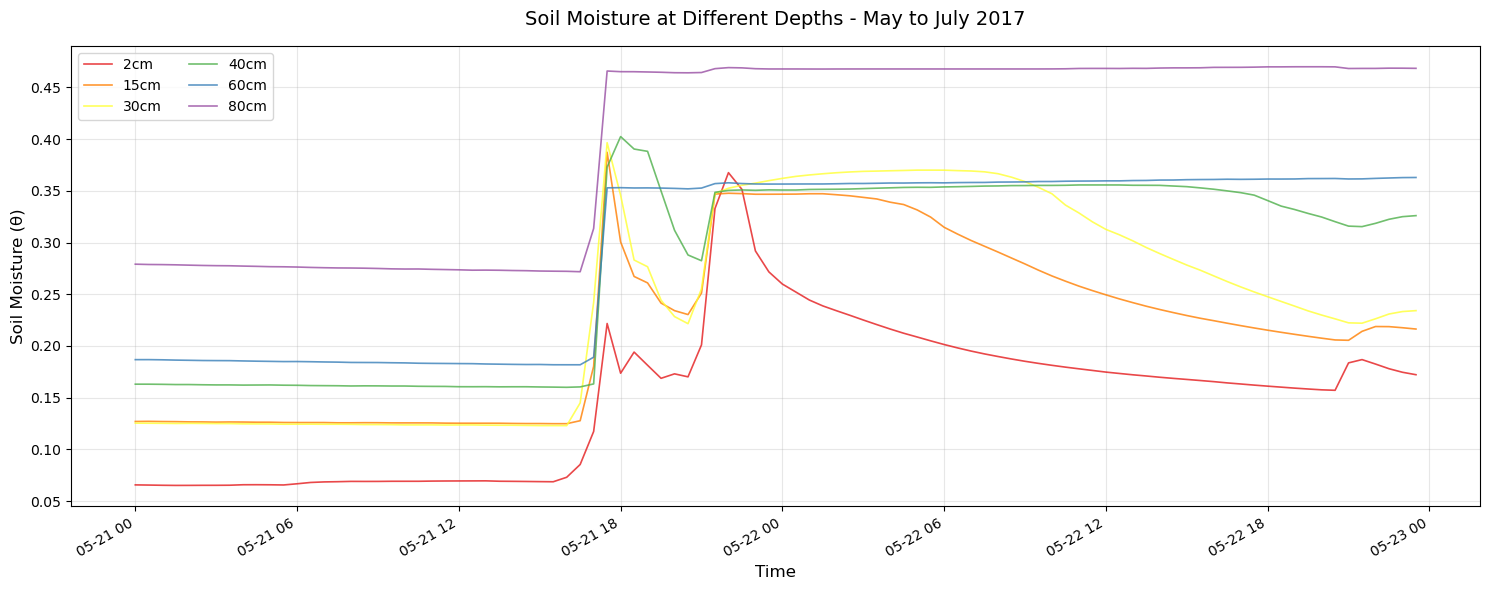


=== Soil Moisture Summary by Depth (May-July 2017) ===

2cm:
  Mean: 0.1520
  Min:  0.0652
  Max:  0.3675
  Valid observations: 96

15cm:
  Mean: 0.2208
  Min:  0.1249
  Max:  0.3872
  Valid observations: 96

30cm:
  Mean: 0.2431
  Min:  0.1230
  Max:  0.3964
  Valid observations: 96

40cm:
  Mean: 0.2793
  Min:  0.1601
  Max:  0.4024
  Valid observations: 96

60cm:
  Mean: 0.2949
  Min:  0.1818
  Max:  0.3628
  Valid observations: 96

80cm:
  Mean: 0.3981
  Min:  0.2718
  Max:  0.4698
  Valid observations: 96


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ========== Load Soil Moisture Data ==========
sm_path = "/Users/jasonjing/Documents/smap/SMAP-Recharge-Flux/data/2017_HalfHourly_UTC_ForestSite1.xlsx"

# Load Excel with multi-level headers
sm_df_raw = pd.read_excel(sm_path, header=[0, 1])

# Extract time and all theta columns
time_col = ('Unnamed: 0_level_0', 'Date Time')
theta_cols = {
    '2cm': ('CR1000_2589', '2cm theta'),
    '15cm': ('CR1000_2589', '15cm theta'),
    '40cm': ('CR1000_2589', '40cm theta'),
    '30cm': ('CR1000_2588', '30cm_theta'),
    '60cm': ('CR1000_2588', '60cm_theta'),
    '80cm': ('CR1000_2588', '80cm_theta'),
}

# Create a new dataframe with flattened columns
theta_df = pd.DataFrame()
theta_df['time'] = pd.to_datetime(sm_df_raw[time_col], errors='coerce')

# Extract all theta columns
for depth_name, col_tuple in theta_cols.items():
    theta_df[depth_name] = pd.to_numeric(sm_df_raw[col_tuple], errors='coerce')
    # Replace missing data indicators (negative values like -9999) with NaN
    theta_df.loc[theta_df[depth_name] < 0, depth_name] = np.nan

# Filter for May 2017 to July 2017 (2017-05 to 2017-07)
theta_df = theta_df[(theta_df['time'] >= '2017-05-21') & (theta_df['time'] < '2017-05-23')]
theta_df = theta_df.sort_values('time').reset_index(drop=True)

# ========== Plot All Theta Levels ==========
fig, ax = plt.subplots(figsize=(15, 6))

# Define colors for different depths
colors = ['#e41a1c', '#ff7f00', '#ffff33', '#4daf4a', '#377eb8', '#984ea3']
depths = ['2cm', '15cm', '30cm', '40cm', '60cm', '80cm']

# Plot each depth
for depth, color in zip(depths, colors):
    if depth in theta_df.columns:
        # Remove NaN for plotting
        plot_data = theta_df[['time', depth]].dropna()
        ax.plot(plot_data['time'], plot_data[depth], 
                label=f'{depth}', color=color, lw=1.2, alpha=0.8)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Soil Moisture (θ)', fontsize=12)
ax.set_title('Soil Moisture at Different Depths - May to July 2017', fontsize=14, pad=15)
ax.legend(loc='best', ncol=2)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

# Show summary statistics for each depth
print("\n=== Soil Moisture Summary by Depth (May-July 2017) ===")
for depth in depths:
    if depth in theta_df.columns:
        valid_data = theta_df[depth].dropna()
        if len(valid_data) > 0:
            print(f"\n{depth}:")
            print(f"  Mean: {valid_data.mean():.4f}")
            print(f"  Min:  {valid_data.min():.4f}")
            print(f"  Max:  {valid_data.max():.4f}")
            print(f"  Valid observations: {len(valid_data)}")